In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# We assume that the project folder is located in the home directory
home_dir = os.path.expanduser("~")
sys.path.insert(0, os.path.abspath(os.path.join(home_dir, 'DSAIT4030-group12')))

from diffuser.diffuser_ddpm_linear_schedule import Diffuser_DDPM_linear_schedule 
from diffuser.unet import DiffusionUNet

from dataset_loader import load_dataset
from torch.utils.data import DataLoader
from vae.vae import VAE

# Config:
from diffuser.unet_config import DiffuserConfig

/home/remcohuijsen/anaconda3/envs/diffusion_fresh/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [2]:
#Init
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(0)
np.random.seed(0)

cuda


In [3]:
# Create scheduler model
ddpm_model = Diffuser_DDPM_linear_schedule(total_timesteps=1000, beta_start=0.0001, beta_end=0.02)

ddpm_model.betas = ddpm_model.betas.to(device)
ddpm_model.alphas = ddpm_model.alphas.to(device)
ddpm_model.alpha_bars = ddpm_model.alpha_bars.to(device)

In [4]:
# Create model
config = DiffuserConfig()
unet = DiffusionUNet(
    config=config,
    model_in_channels=4,
    model_out_channels=4
).to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=2e-4, weight_decay=1e-5)


In [5]:
# Load VAE
vae = VAE(mode="kl").to(device)
checkpoint = torch.load("../step_100000.pt", map_location=device, weights_only=False)

vae.load_state_dict(checkpoint["vae"], strict=False)

<All keys matched successfully>

In [6]:
# Loads data and uses VAE to generate latents
def load_data(NUM_WORKERS, BATCH_SIZE, DATASET):
    train_set = load_dataset(DATASET, split="train")

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
        persistent_workers=True if NUM_WORKERS > 0 else False,
    )

    return train_loader

In [7]:
def train_step(data, batch_size, minibatch_size, model, ddpm):
    
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0

    number_of_minibatches = batch_size // minibatch_size

    for batch_idx, batch in enumerate(data):

        data_minibatch = batch["images"].to(device, non_blocking=True)
        
        data_minibatch = vae.encode(data_minibatch)

        # Randomly sample diffusion timesteps for each data sample in the minibatch.
        B = data_minibatch.shape[0]
        t = torch.randint(0, ddpm.total_timesteps, (B,), device=device, dtype=torch.long).view(-1)

        # Perform a forward diffusion step to time t and retrieve the corresponding noisy sample x_t and the true added noise.
        x_t, true_noise = ddpm.forward_diffusion(data_minibatch, t)
        
        # Let the prediction model predict the added noise given the noisy sample x_t and the diffusion timestep t.
        pred_noise = model(x_t, t)
        
        # Compute the loss as the mean squared error and normalize based on the number of minibatches.
        loss = F.mse_loss(pred_noise, true_noise) / number_of_minibatches
        
        # Perform backward pass to compute gradient per minibatch.
        loss.backward()

        total_loss += loss.detach().item()

        if batch_idx >= number_of_minibatches - 1:
            break
        
    # Perform an optimization step based on the accumulated gradients of all minibatches.
    optimizer.step()

    return total_loss


# Sampling

In [8]:
@torch.no_grad()
def sample(model, ddpm, shape, fixed_noise=None):
    model.eval()

    x = torch.randn(shape, device=device)

    if fixed_noise != None:
        x = fixed_noise

    for t in range(ddpm.total_timesteps - 1, 0, -1):
        ts = torch.full((shape[0],), t, device=device, dtype=torch.long).view(-1)
        pred_noise = model(x, ts)
        x = ddpm.reverse_diffusion(x, ts, pred_noise)

    return x

In [9]:
def show_images(img_batch, title=None):
    img_batch = img_batch.detach().cpu()
    fig, axes = plt.subplots(1, img_batch.shape[0], figsize=(4 * img_batch.shape[0], 4))
    if img_batch.shape[0] == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        img = img_batch[i]
        img = (img + 1.0) / 2.0
        img = (img * 255.0).clamp(0, 255).byte()
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

# Run and Show

/home/remcohuijsen
step     0 | loss 1.1088


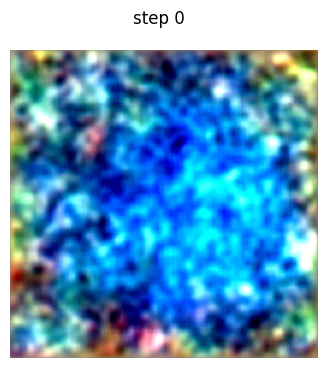

/home/remcohuijsen
step     1 | loss 2.7648
/home/remcohuijsen
step     2 | loss 1.3329
/home/remcohuijsen
step     3 | loss 1.0921
/home/remcohuijsen
step     4 | loss 1.0035
/home/remcohuijsen
step     5 | loss 1.0167
/home/remcohuijsen
step     6 | loss 1.0346
/home/remcohuijsen
step     7 | loss 1.0227
/home/remcohuijsen
step     8 | loss 1.0104
/home/remcohuijsen
step     9 | loss 1.0125
/home/remcohuijsen
step    10 | loss 1.0180
/home/remcohuijsen
step    11 | loss 1.0161
/home/remcohuijsen
step    12 | loss 1.0084
/home/remcohuijsen
step    13 | loss 0.9947
/home/remcohuijsen
step    14 | loss 1.0023
/home/remcohuijsen
step    15 | loss 1.0083
/home/remcohuijsen
step    16 | loss 1.0061
/home/remcohuijsen
step    17 | loss 1.0069
/home/remcohuijsen
step    18 | loss 1.0024
/home/remcohuijsen
step    19 | loss 1.0035
/home/remcohuijsen
step    20 | loss 1.0025
/home/remcohuijsen
step    21 | loss 1.0072
/home/remcohuijsen
step    22 | loss 1.0019
/home/remcohuijsen
step    23 | 

KeyboardInterrupt: 

In [10]:
# training loop:
num_steps = 10000
batch_size = 64
minibatch_size = 4
num_workers = 0
loss_history = []

print_loss_every = 1
preview_every = 100

for step in range(num_steps):
    data = load_data(num_workers, minibatch_size, "celeba")
    loss = train_step(data, batch_size, minibatch_size, unet, ddpm_model)
    loss_history.append(loss)

    if step % print_loss_every == 0:
        print(f"step {step:5d} | loss {loss:.4f}")

    if step % preview_every == 0:
        unet.eval()
        with torch.no_grad():
            latent_samples = sample(unet, ddpm_model, (1, 4, 32, 32))
            samples = vae.decode(latent_samples)
        show_images(samples, title=f"step {step}")
        unet.train()


In [ ]:
show_images(samples, title="Generated samples")

In [ ]:
samples = vae.decode(sample(unet, ddpm_model, (1, 4, 32, 32)))
